In [20]:
import numpy as nm
import matplotlib.pyplot as mtp
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [21]:
nm.random.seed(42)
n = 80

student_ids = nm.arange(1, n + 1)
gpa = nm.round(nm.clip(nm.random.normal(2.8, 0.6, n), 1.0, 4.0), 2)
study_hours = nm.round(nm.clip(nm.random.normal(15, 6, n), 2, 40), 1)
attendance_rate = nm.round(nm.clip(nm.random.normal(75, 15, n), 30, 100), 1)


In [22]:
df = pd.DataFrame({
    'student_id': student_ids,
    'GPA': gpa,
    'study_hours': study_hours,
    'attendance_rate': attendance_rate
})

x = df[['GPA', 'study_hours', 'attendance_rate']].values

x

array([[  3.1 ,  13.7 ,  60.4 ],
       [  2.72,  17.1 ,  86.8 ],
       [  3.19,  23.9 ,  92.4 ],
       [  3.71,  11.9 ,  62.7 ],
       [  2.66,  10.1 ,  89.5 ],
       [  2.66,  12.  ,  81.2 ],
       [  3.75,  20.5 ,  87.3 ],
       [  3.26,  17.  , 100.  ],
       [  2.52,  11.8 ,  71.3 ],
       [  3.13,  18.1 ,  63.7 ],
       [  2.52,  15.6 ,  61.7 ],
       [  2.52,  20.8 ,  62.8 ],
       [  2.95,  10.8 ,  73.8 ],
       [  1.65,  13.  ,  80.1 ],
       [  1.77,  12.6 ,  79.2 ],
       [  2.46,   6.2 ,  87.4 ],
       [  2.19,  16.8 ,  75.2 ],
       [  2.99,  16.6 ,  96.8 ],
       [  2.26,  15.  ,  71.  ],
       [  1.95,  13.6 , 100.  ],
       [  3.68,   6.5 ,  84.4 ],
       [  2.66,  12.5 ,  62.1 ],
       [  2.84,  12.9 ,  58.9 ],
       [  1.95,  10.2 ,  82.2 ],
       [  2.47,  14.  ,  71.6 ],
       [  2.87,  17.4 ,  85.7 ],
       [  2.11,  26.3 ,  82.1 ],
       [  3.03,  16.  ,  73.9 ],
       [  2.44,  16.5 ,  62.3 ],
       [  2.62,  14.6 ,  52.3 ],
       [  

In [23]:
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

x_scaled

array([[ 0.65537025, -0.22495425, -1.17807313],
       [-0.01029148,  0.39687051,  0.80874349],
       [ 0.81302697,  1.64052005,  1.23018944],
       [ 1.72393249, -0.5541556 , -1.00497926],
       [-0.11539596, -0.88335695,  1.01194064],
       [-0.11539596, -0.53586664,  0.38729754],
       [ 1.79400215,  1.01869528,  0.84637259],
       [ 0.93564887,  0.37858155,  1.8021518 ],
       [-0.36063976, -0.57244457, -0.35775869],
       [ 0.70792249,  0.57976015, -0.92972105],
       [-0.36063976,  0.12253606, -1.08023746],
       [-0.36063976,  1.07356217, -0.99745344],
       [ 0.39260904, -0.7553342 , -0.16961318],
       [-1.88465476, -0.352977  ,  0.30451351],
       [-1.6744458 , -0.42613286,  0.23678113],
       [-0.46574424, -1.59662654,  0.85389841],
       [-0.93871442,  0.34200362, -0.06425169],
       [ 0.46267869,  0.30542569,  1.56132554],
       [-0.81609252,  0.01280227, -0.38033615],
       [-1.35913235, -0.24324322,  1.8021518 ],
       [ 1.67138025, -1.54175965,  0.628

In [24]:
wcss = []
k_range = range(2, 7)
for k in k_range:
    km = KMeans(n_clusters=k, init='k-means++', random_state=42)
    km.fit(x_scaled)
    wcss.append(km.inertia_)

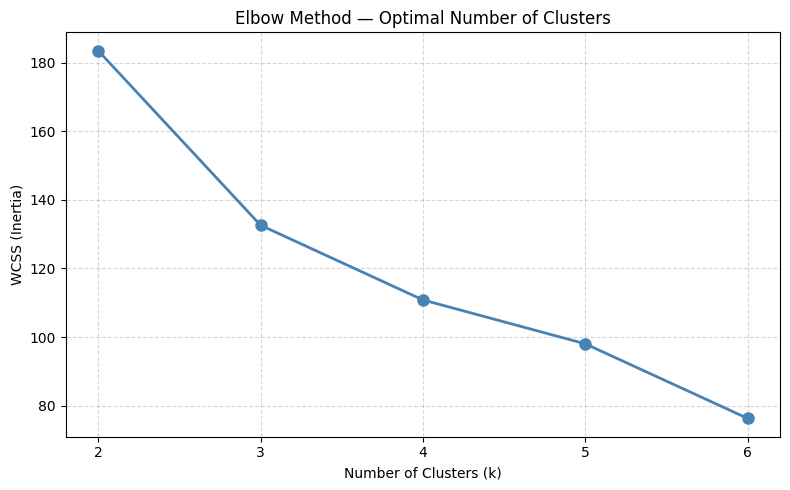

In [25]:

mtp.figure(figsize=(8, 5))
mtp.plot(list(k_range), wcss, marker='o', color='steelblue', linewidth=2, markersize=8)
mtp.title('Elbow Method — Optimal Number of Clusters')
mtp.xlabel('Number of Clusters (k)')
mtp.ylabel('WCSS (Inertia)')
mtp.xticks(list(k_range))
mtp.grid(True, linestyle='--', alpha=0.5)
mtp.tight_layout()
mtp.show()

In [26]:
optimal_k = 4

kmeans_final = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42)
df['cluster'] = kmeans_final.fit_predict(x_scaled)

cluster_labels = {
    0: 'Low Engagement',
    1: 'High Performers',
    2: 'Moderate Engagement',
    3: 'At-Risk Students'
}

df['cluster_label'] = df['cluster'].map(cluster_labels)

colors = ['#e74c3c', '#2ecc71', '#3498db', '#f39c12']
cluster_names = [cluster_labels[i] for i in range(optimal_k)]

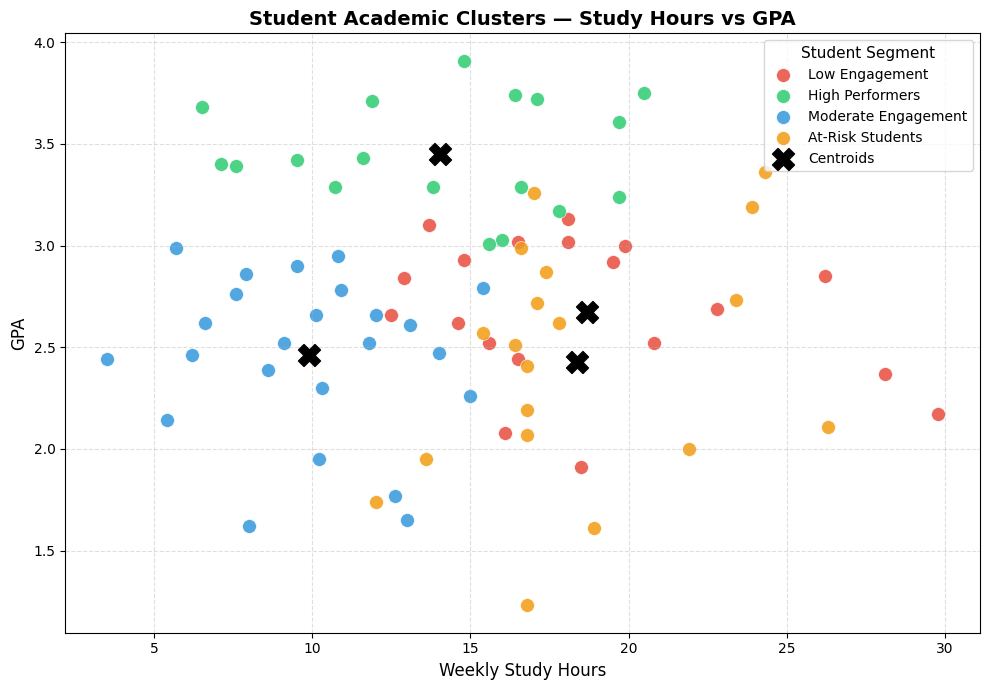

In [27]:
mtp.figure(figsize=(10, 7))
for i in range(optimal_k):
    subset = df[df['cluster'] == i]
    mtp.scatter(
        subset['study_hours'],
        subset['GPA'],
        s=100,
        c=colors[i],
        label=cluster_names[i],
        edgecolors='white',
        linewidths=0.5,
        alpha=0.85
    )

centers_original = scaler.inverse_transform(kmeans_final.cluster_centers_)
mtp.scatter(
    centers_original[:, 1],
    centers_original[:, 0],
    s=250,
    c='black',
    marker='X',
    label='Centroids',
    zorder=5
)

mtp.title('Student Academic Clusters — Study Hours vs GPA', fontsize=14, fontweight='bold')
mtp.xlabel('Weekly Study Hours', fontsize=12)
mtp.ylabel('GPA', fontsize=12)
mtp.legend(title='Student Segment', fontsize=10, title_fontsize=11)
mtp.grid(True, linestyle='--', alpha=0.4)
mtp.tight_layout()
mtp.show()

In [28]:
print("Final Dataset with Cluster Assignments:")
print(df[['student_id', 'GPA', 'study_hours', 'attendance_rate', 'cluster', 'cluster_label']].to_string(index=False))

print("Cluster Summary Statistics:")
print(df.groupby('cluster_label')[['GPA', 'study_hours', 'attendance_rate']].mean().round(2))

print("Cluster Sizes:")
print(df['cluster_label'].value_counts())


Final Dataset with Cluster Assignments:
 student_id  GPA  study_hours  attendance_rate  cluster       cluster_label
          1 3.10         13.7             60.4        0      Low Engagement
          2 2.72         17.1             86.8        3    At-Risk Students
          3 3.19         23.9             92.4        3    At-Risk Students
          4 3.71         11.9             62.7        1     High Performers
          5 2.66         10.1             89.5        2 Moderate Engagement
          6 2.66         12.0             81.2        2 Moderate Engagement
          7 3.75         20.5             87.3        1     High Performers
          8 3.26         17.0            100.0        3    At-Risk Students
          9 2.52         11.8             71.3        2 Moderate Engagement
         10 3.13         18.1             63.7        0      Low Engagement
         11 2.52         15.6             61.7        0      Low Engagement
         12 2.52         20.8             62.8  